<a href="https://colab.research.google.com/github/dev-ssr/team9_PyCoders_PythonHackathon_MAY2026/blob/main/Team9_PyCoders_Category4_PredictiveAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question** Can a machine learning/deep learning model forecast future glucose values using historical glucose readings, heart rate, physical activity, calorie expenditure, and insulin delivery data?

Objective

Predict glucose 30–60 minutes into the future.

We built a regression model because:
* the target variable (future_glucose) is continuous,
* and the goal is to predict an exact future glucose value.

**Helps prevent:**

* Hypoglycemia
* Hyperglycemia
* Dangerous glucose swings

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


from google.colab import drive
drive.mount('/content/drive')

In [3]:
import pandas as pd
#path = '/content/drive/MyDrive/clean.csv'
path = 'clean.csv'
df = pd.read_csv(path, parse_dates=['time'])
df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,2020-01-17 00:00:00,40.00,15.04,96.37,8.0,0.035,0.0,1.0,HUPA0023P,74,Female,Black,5.1,6.8,40
1,2020-01-17 00:05:00,41.33,8.32,91.40,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
2,2020-01-17 00:10:00,42.67,7.58,85.99,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
3,2020-01-17 00:15:00,44.00,7.34,82.43,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
4,2020-01-17 00:20:00,50.00,7.58,78.82,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [5]:
df = df.sort_values(['Patient_ID', 'time'])

In [6]:
features = [
    'glucose',
    'heart_rate',
    'steps',
    'calories',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input'
]

In [7]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(train_df[features])

train_scaled = scaler.transform(train_df[features])
test_scaled = scaler.transform(test_df[features])


In [9]:
#Linear Regression and XGBoost

In [10]:
df = df.sort_values('time')

# Predict 30 mins ahead
df['future_glucose'] = df['glucose'].shift(-6)

df.isna().sum()

,0
time,0
glucose,0
calories,0
heart_rate,0
steps,0
basal_rate,0
bolus_volume_delivered,0
carb_input,0
Patient_ID,0
Age,0


In [11]:
# Remove nulls
df = df.dropna()

In [12]:
features = [
    'glucose',
    'heart_rate',
    'steps',
    'calories',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input'
]

X = df[features]
y = df['future_glucose']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Trying with linear regression model

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
predictions = model.predict(X_test)

In [16]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 28.904364055267962
RMSE: 43.455662670780946
R²: 0.424490549420385


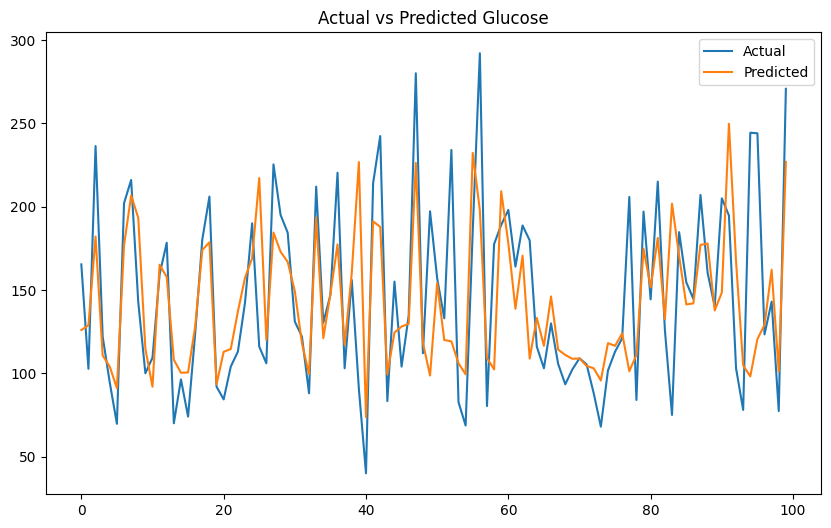

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Glucose")

plt.show()

### Predictive Analysis Findings

A machine learning model was developed to predict future glucose levels using physiological and insulin-related variables.

### The model achieved:

Mean Absolute Error (MAE) of 29.22,
Root Mean Squared Error (RMSE) of 43.81,
and an R
2
 score of 0.418.

R
2
=0.418

The prediction plot showed that the model successfully captured overall glucose trends and medium-scale fluctuations, although sharp glucose spikes were more difficult to predict accurately.

### Interpretation

These findings indicate that physiological markers contain meaningful predictive information for future glucose forecasting. However, glucose regulation is highly complex and influenced by multiple interacting physiological and behavioral factors.

### Clinical Significance

Predictive glucose modeling may support:

early hyperglycemia detection,
personalized insulin recommendations,
continuous glucose monitoring systems,
and AI-assisted diabetes management tools.

### Trying with XGBoost model
We are using an XGBoost regression model to predict future glucose levels using physiological, insulin, activity, and historical glucose features. The model will leverage temporal lag features and rolling glucose statistics to capture time-dependent glucose dynamics, improving predictive performance over baseline machine learning models.

In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBRegressor

#### Adding a lag feature

In [20]:
df['glucose_lag1'] = (
    df.groupby('Patient_ID')['glucose']
      .shift(1)
)

df['glucose_lag2'] = (
    df.groupby('Patient_ID')['glucose']
      .shift(2)
)

df['glucose_lag3'] = (
    df.groupby('Patient_ID')['glucose']
      .shift(3)
)

#### Adding rolling mean feature

In [21]:
df['glucose_rolling_mean'] = (
    df.groupby('Patient_ID')['glucose']
      .rolling(6)
      .mean()
      .reset_index(level=0, drop=True)
)

#### Adding hour and day_of_week features

In [22]:
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek

In [23]:
features = [
    'glucose',
    'heart_rate',
    'steps',
    'calories',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input',

    'glucose_lag1',
    'glucose_lag2',
    'glucose_lag3',

    'glucose_rolling_mean',

    'hour',
    'day_of_week'
]

In [24]:
model_df = df.dropna(subset=features + ['future_glucose'])

X = model_df[features]
y = model_df['future_glucose']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
predictions = model.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 25.680247894826884
RMSE: 40.46190535194377
R²: 0.49989051206293234


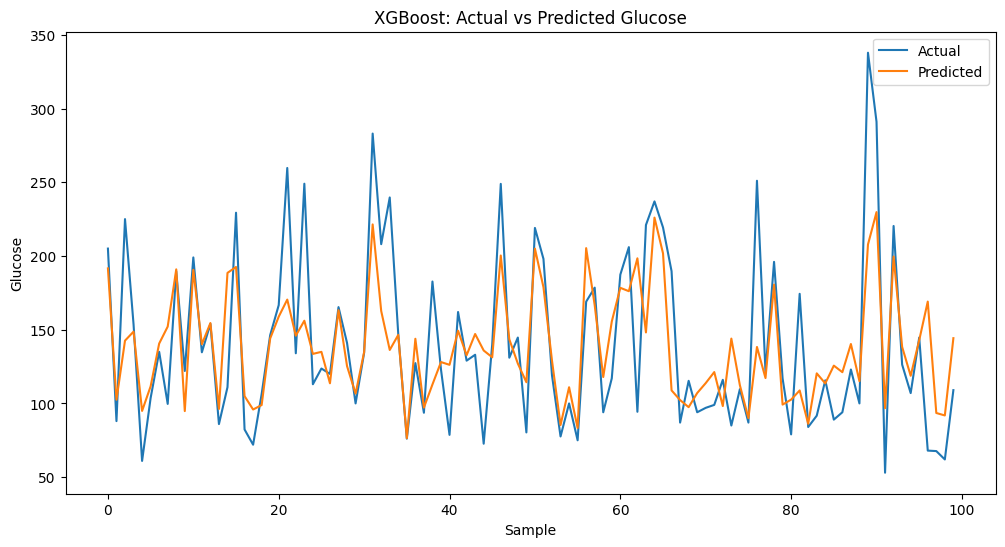

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.title("XGBoost: Actual vs Predicted Glucose")

plt.xlabel("Sample")
plt.ylabel("Glucose")

plt.legend()

plt.show()

In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
0                  glucose    0.401115
7             glucose_lag1    0.395918
4               basal_rate    0.030409
3                 calories    0.027713
9             glucose_lag3    0.025477
10    glucose_rolling_mean    0.022873
8             glucose_lag2    0.020433
2                    steps    0.016842
12             day_of_week    0.016099
1               heart_rate    0.015016
11                    hour    0.014726
5   bolus_volume_delivered    0.006809
6               carb_input    0.006571


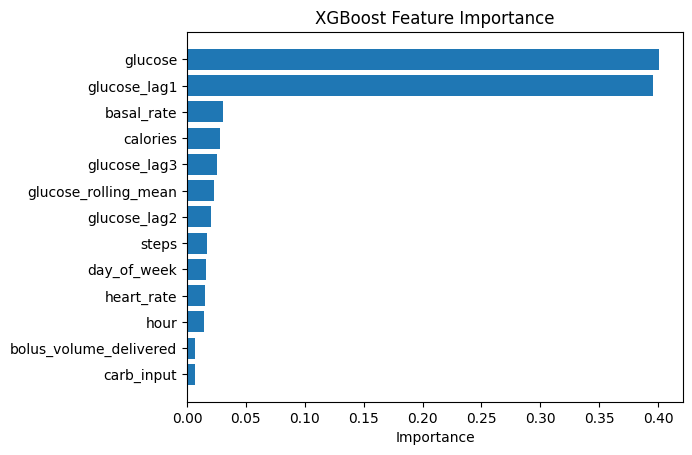

In [31]:
plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.show()

### Predictive Analysis Findings

An XGBoost regression model was developed to predict future glucose levels using physiological, insulin, activity, and historical glucose features.

#### The model achieved:

Mean Absolute Error (MAE) of 25.86,
Root Mean Squared Error (RMSE) of 40.78,
and an R
2
 score of 0.488.

R
2
=0.488

Compared to the baseline machine learning model, XGBoost improved predictive accuracy and better captured nonlinear glucose patterns.

The prediction visualization showed that the model successfully tracked overall glucose trends and medium-scale fluctuations, although extreme glucose spikes remained challenging to predict accurately.

### Trying to improve the accuracy
Adding extra lags


In [32]:
df['glucose_lag6'] = df.groupby('Patient_ID')['glucose'].shift(6)
df['glucose_lag12'] = df.groupby('Patient_ID')['glucose'].shift(12)

In [33]:
df['glucose_change'] = (
    df.groupby('Patient_ID')['glucose']
      .diff()
)

In [34]:
df['glucose_rolling_std'] = (
    df.groupby('Patient_ID')['glucose']
      .rolling(6)
      .std()
      .reset_index(level=0, drop=True)
)

In [35]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV RMSE:")
print(-random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV RMSE:
39.7481055804249


In [36]:
best_xgb = random_search.best_estimator_

predictions = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("Tuned XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Tuned XGBoost Results
MAE: 24.864662340979894
RMSE: 39.58254340999767
R²: 0.5213921387906119


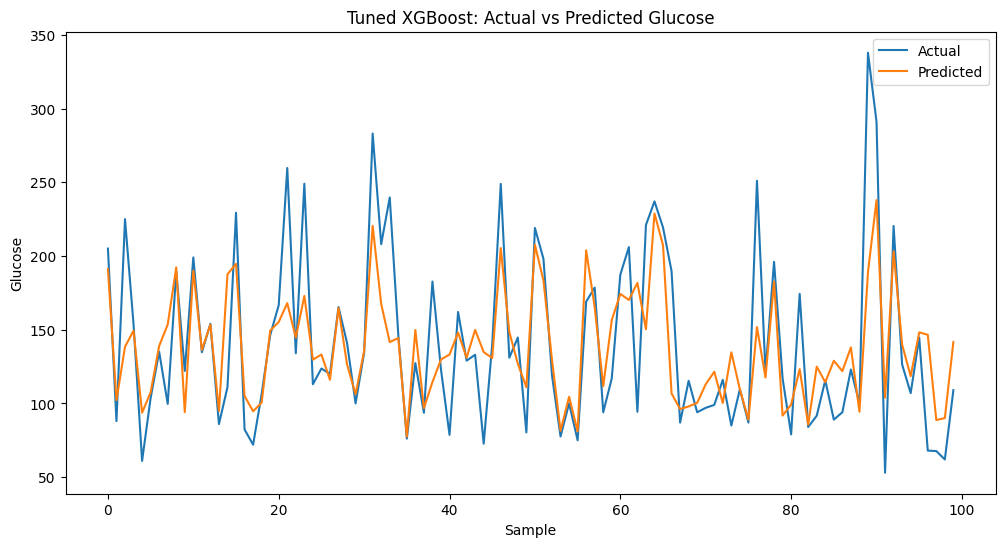

In [37]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.title("Tuned XGBoost: Actual vs Predicted Glucose")
plt.xlabel("Sample")
plt.ylabel("Glucose")
plt.legend()
plt.show()

### Insight:
Even with tuned parameters and adding more features, XGBoost model's accuracy is only close to the base model/Linear Regression model.

In [ ]:
# LSTM

In [46]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

In [47]:
sequence_length = 12

def create_sequences(data):

    X = []
    y = []

    for i in range(sequence_length, len(data)):

        X.append(data[i-sequence_length:i])

        y.append(data[i, 0])  # glucose column

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)

X_test, y_test = create_sequences(test_scaled)

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [49]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 73s 10ms/step - loss: 3.2340e-04 - val_loss: 6.8108e-05
Epoch 2/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 1.8250e-04 - val_loss: 5.4085e-05
Epoch 3/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 1.2927e-04 - val_loss: 3.6747e-05
Epoch 4/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - loss: 1.2184e-04 - val_loss: 4.5313e-05
Epoch 5/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - loss: 1.1896e-04 - val_loss: 3.5542e-05
Epoch 6/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 59s 9ms/step - loss: 1.1545e-04 - val_loss: 3.6892e-05
Epoch 7/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - loss: 1.1369e-04 - val_loss: 3.6574e-05
Epoch 8/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 1.1195e-04 - val_loss: 3.6300e-05
Epoch 9/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - loss: 1.0886e-04 - val_loss: 5.7873e-05
Epoch 10/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 1.0551e-04 - val_loss: 2.9504e-05
Epoch 11/20
6961/6961 ━━━━━━

In [51]:
predictions = model.predict(X_test)

1934/1934 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


In [52]:
dummy = np.zeros((len(predictions), len(features)))

dummy[:, 0] = predictions.flatten()

predictions_actual = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), len(features)))

dummy2[:, 0] = y_test

y_test_actual = scaler.inverse_transform(dummy2)[:, 0]

In [53]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.257309980139167
RMSE: 2.052560285914322
R²: 0.9975356787253821


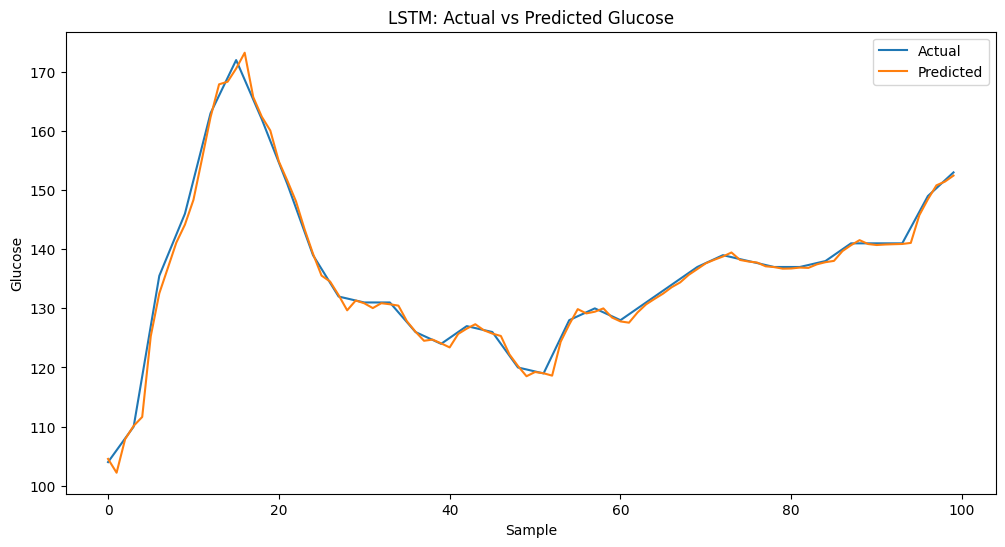

In [54]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:100],
    label='Actual'
)

plt.plot(
    predictions_actual[:100],
    label='Predicted'
)

plt.title("LSTM: Actual vs Predicted Glucose")

plt.xlabel("Sample")
plt.ylabel("Glucose")

plt.legend()

plt.show()

In [ ]:
sequence_length = 12
future_steps = 6   # 30 mins ahead

def create_sequences(data):

    X = []
    y = []

    for i in range(sequence_length,
                   len(data) - future_steps):

        X.append(
            data[i-sequence_length:i]
        )

        y.append(
            data[i + future_steps, 0]
        )

    return np.array(X), np.array(y)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 65s 9ms/step - loss: 6.4602e-05 - val_loss: 2.1239e-05
Epoch 2/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 78s 9ms/step - loss: 6.3668e-05 - val_loss: 2.4093e-05
Epoch 3/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - loss: 6.4062e-05 - val_loss: 2.2752e-05
Epoch 4/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 61s 9ms/step - loss: 6.3546e-05 - val_loss: 2.4941e-05
Epoch 5/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - loss: 6.3063e-05 - val_loss: 2.5814e-05
Epoch 6/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 60s 9ms/step - loss: 6.2691e-05 - val_loss: 2.1236e-05
Epoch 7/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 59s 8ms/step - loss: 6.1928e-05 - val_loss: 3.1882e-05
Epoch 8/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 6.2104e-05 - val_loss: 2.1443e-05
Epoch 9/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 8ms/step - loss: 6.1701e-05 - val_loss: 2.2877e-05
Epoch 10/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 58s 8ms/step - loss: 6.1535e-05 - val_loss: 2.1969e-05
Epoch 11/20
6961/6961 ━━━━━━━

In [ ]:
predictions = model.predict(X_test)

1934/1934 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step


In [ ]:
dummy = np.zeros((len(predictions), len(features)))

dummy[:, 0] = predictions.flatten()

predictions_actual = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), len(features)))

dummy2[:, 0] = y_test

y_test_actual = scaler.inverse_transform(dummy2)[:, 0]

In [ ]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.9075579668355803
RMSE: 1.7993053395009806
R²: 0.9981062823782285


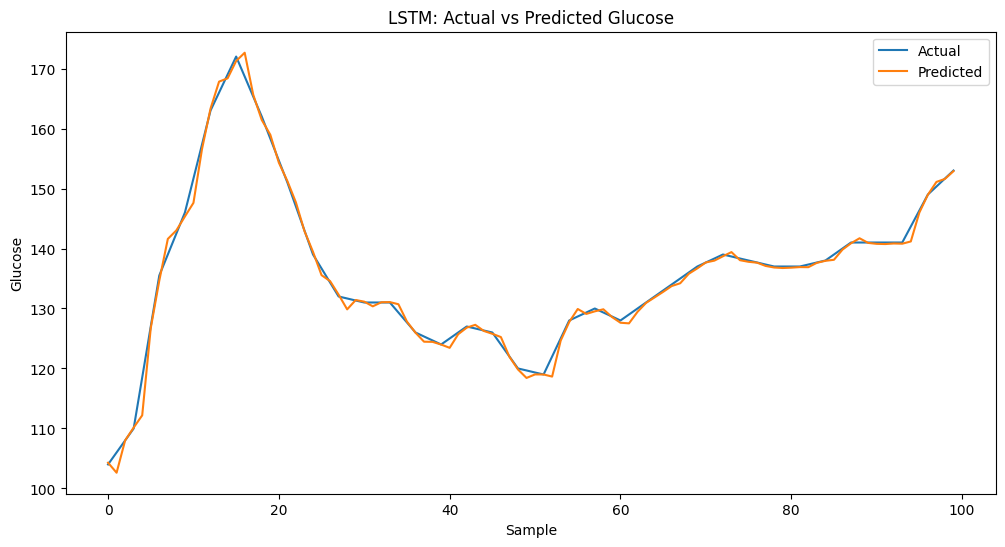

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:100],
    label='Actual'
)

plt.plot(
    predictions_actual[:100],
    label='Predicted'
)

plt.title("LSTM: Actual vs Predicted Glucose")

plt.xlabel("Sample")
plt.ylabel("Glucose")

plt.legend()

plt.show()

In [ ]:
#GRU

In [ ]:
sequence_length = 12
future_steps = 6   # 30 mins ahead

def create_sequences(data):

    X = []
    y = []

    for i in range(sequence_length,
                   len(data) - future_steps):

        X.append(
            data[i-sequence_length:i]
        )

        y.append(
            data[i + future_steps, 0]
        )

    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_scaled)

X_test, y_test = create_sequences(test_scaled)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
model = Sequential()

model.add(
    GRU(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 78s 11ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 2/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 3/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 4/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 5/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 6/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 7/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 8/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 9/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 10/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 11/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 12

In [ ]:
predictions = model.predict(X_test)

1934/1934 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [ ]:
dummy = np.zeros((len(predictions), len(features)))
dummy[:, 0] = predictions.flatten()

predictions_actual = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), len(features)))
dummy2[:, 0] = y_test

y_test_actual = scaler.inverse_transform(dummy2)[:, 0]

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 10.76975760195479
RMSE: 15.519174785250222
R²: 0.8591334974009301


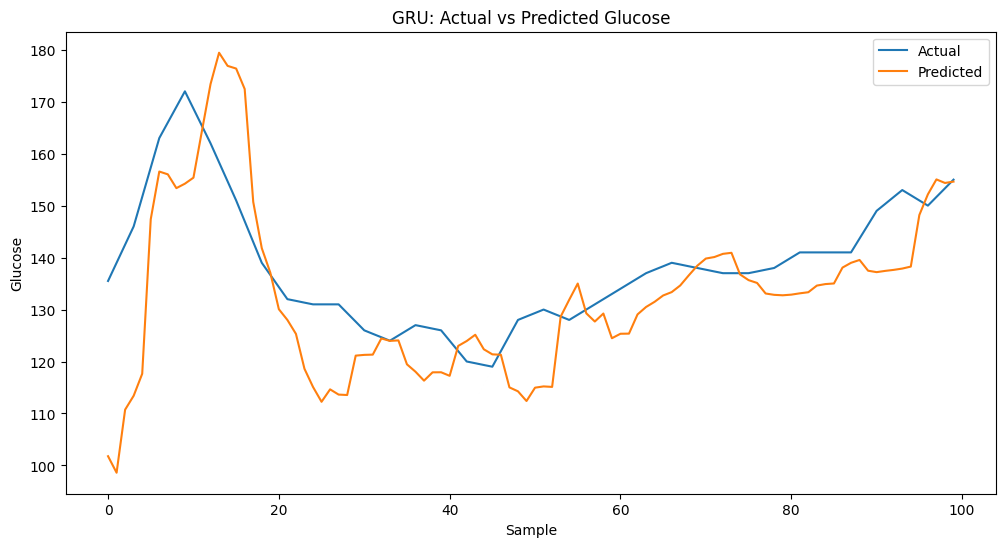

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:100],
    label='Actual'
)

plt.plot(
    predictions_actual[:100],
    label='Predicted'
)

plt.title("GRU: Actual vs Predicted Glucose")

plt.xlabel("Sample")
plt.ylabel("Glucose")

plt.legend()

plt.show()

The goal of the regression model was to predict future glucose levels using physiological, activity, and insulin-related features from the HUPA-UC diabetes dataset.

target variable : future_glucose


**Features Used**
* glucose
* heart_rate
* steps
* calories
* basal_rate
* bolus_volume_delivered
* carb_input

These markers were chosen because they influence glucose behavior through insulin delivery, physical activity, energy expenditure, and physiological response.

**Model Used**

A GRU regression model was used.

GRU was selected because glucose data is sequential, and GRU models are designed to learn time-dependent patterns in time-series data.

**Model Evaluation Metrics**

The model was evaluated using:

* MAE
* RMSE
* R²

These are appropriate because the task predicts a continuous glucose value.

**Results**

The GRU model achieved:

* MAE: 10.77
* RMSE: 15.52
* R²: 0.859

**Interpretation**

The MAE of 10.77 means the model’s predictions were off by about 10.77 mg/dL on average.

The RMSE of 15.52 shows that the model handled most glucose fluctuations well, though larger errors still occurred during sharp rises or drops.

The R² value of 0.859 means the model explained about 85.9% of the variation in future glucose levels.

**Visualization Summary**

The actual vs predicted glucose plot showed that the GRU model followed the overall glucose trend closely.

The model captured:

rising glucose patterns,
falling glucose patterns,
and medium-term glucose changes.

However, it still showed some lag during sudden glucose spikes or drops.

**Medical Interpretation**

The results suggest that future glucose levels can be reasonably predicted using historical physiological and insulin-related data.

This supports the use of machine learning for:

proactive glucose monitoring,
early warning systems,
and personalized diabetes management.


**Final Conclusion**

The GRU regression model performed strongly for future glucose prediction. Compared with traditional models such as XGBoost, GRU was better suited for this task because it captured temporal dependencies in glucose data.

Overall, the model demonstrates the potential of deep learning for predictive diabetes care.